# TD3 - Modeling and Evaluation — Ayman Chabbaki (G1)

This notebook implements the TD3 (Twin Delayed Deep Deterministic Policy Gradient) algorithm for continuous control environments. Objectives:
- Build actor and critic networks with PyTorch
- Implement TD3 training loop with replay buffer, target smoothing, and delayed policy updates
- Train and evaluate on a standard continuous-control gym environment (e.g., Pendulum)
- Visualize training metrics and save the trained policy

## Requirements

Install required packages (preferably in a venv):

```bash
pip install torch gymnasium[accept-roms] gym matplotlib numpy tqdm
```

Notes:
- If `gymnasium` is not available, the notebook will fallback to `gym`.
- Training TD3 requires PyTorch. For CUDA, install the appropriate `torch` build.

In [14]:
# Imports and settings
import math
import random
from pathlib import Path
import numpy as np
import collections
import matplotlib.pyplot as plt
from tqdm import trange

# PyTorch with graceful fallback warning
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    import torch.optim as optim
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
except Exception as e:
    raise RuntimeError('PyTorch is required for this notebook. Install torch before running.')

# gym / gymnasium fallback
try:
    import gymnasium as gym
except Exception:
    import gym

print('Device:', device)

%matplotlib inline
try:
    plt.style.use('seaborn-v0_8')
except OSError:
    try:
        plt.style.use('seaborn-darkgrid')
    except OSError:
        pass


Device: cpu


In [6]:
# Environment setup
ENV_NAME = 'Pendulum-v1'  # continuous-control environment

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# create env
try:
    env = gym.make(ENV_NAME)
except Exception as e:
    raise RuntimeError(f'Failed to create environment {ENV_NAME}: {e}')

obs_space = env.observation_space
act_space = env.action_space

print('Env:', ENV_NAME)
print('Observation space:', obs_space)
print('Action space:', act_space)

# helper: scale actions from [-1,1] to environment action space
action_low = act_space.low
action_high = act_space.high
action_scale = (action_high - action_low) / 2.0
action_bias = (action_high + action_low) / 2.0


Env: Pendulum-v1
Observation space: Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)
Action space: Box(-2.0, 2.0, (1,), float32)


In [7]:
# Actor and Critic networks
class Actor(nn.Module):
    def __init__(self, obs_dim, act_dim, max_action):
        super().__init__()
        self.l1 = nn.Linear(obs_dim, 400)
        self.l2 = nn.Linear(400, 300)
        self.l3 = nn.Linear(300, act_dim)
        self.max_action = max_action

    def forward(self, x):
        x = F.relu(self.l1(x))
        x = F.relu(self.l2(x))
        x = torch.tanh(self.l3(x))
        return x * self.max_action

class Critic(nn.Module):
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        # Q1
        self.l1 = nn.Linear(obs_dim + act_dim, 400)
        self.l2 = nn.Linear(400, 300)
        self.l3 = nn.Linear(300, 1)
        # Q2
        self.l4 = nn.Linear(obs_dim + act_dim, 400)
        self.l5 = nn.Linear(400, 300)
        self.l6 = nn.Linear(300, 1)

    def forward(self, x, u):
        xu = torch.cat([x, u], dim=1)
        x1 = F.relu(self.l1(xu))
        x1 = F.relu(self.l2(x1))
        x1 = self.l3(x1)

        x2 = F.relu(self.l4(xu))
        x2 = F.relu(self.l5(x2))
        x2 = self.l6(x2)
        return x1, x2

    def Q1(self, x, u):
        xu = torch.cat([x,u], dim=1)
        x1 = F.relu(self.l1(xu))
        x1 = F.relu(self.l2(x1))
        x1 = self.l3(x1)
        return x1


In [8]:
# Initialize TD3 components and hyperparameters
obs_dim = obs_space.shape[0]
act_dim = act_space.shape[0]
max_action = float(1.0)  # actor outputs in [-1,1]; scale when sending to env

# hyperparameters
params = {
    'gamma': 0.99,
    'tau': 0.005,
    'policy_noise': 0.2,
    'noise_clip': 0.5,
    'policy_delay': 2,
    'actor_lr': 1e-3,
    'critic_lr': 1e-3,
    'batch_size': 100,
    'start_timesteps': 10000,
    'max_timesteps': 200000,
}

# create networks
actor = Actor(obs_dim, act_dim, max_action).to(device)
actor_target = Actor(obs_dim, act_dim, max_action).to(device)
actor_target.load_state_dict(actor.state_dict())

critic = Critic(obs_dim, act_dim).to(device)
critic_target = Critic(obs_dim, act_dim).to(device)
critic_target.load_state_dict(critic.state_dict())

actor_optimizer = optim.Adam(actor.parameters(), lr=params['actor_lr'])
critic_optimizer = optim.Adam(critic.parameters(), lr=params['critic_lr'])

print('Initialized TD3 components')


Initialized TD3 components


In [9]:
# Replay buffer
class ReplayBuffer:
    def __init__(self, max_size=1_000_000):
        self.max_size = int(max_size)
        self.storage = []
        self.ptr = 0

    def add(self, data):
        if len(self.storage) < self.max_size:
            self.storage.append(data)
        else:
            self.storage[self.ptr] = data
            self.ptr = (self.ptr + 1) % self.max_size

    def sample(self, batch_size):
        ind = np.random.randint(0, len(self.storage), size=batch_size)
        x, y, u, r, d = [], [], [], [], []
        for i in ind:
            state, next_state, action, reward, done = self.storage[i]
            x.append(np.array(state, copy=False))
            y.append(np.array(next_state, copy=False))
            u.append(np.array(action, copy=False))
            r.append(np.array(reward, copy=False))
            d.append(np.array(done, copy=False))
        return (
            torch.FloatTensor(np.array(x)).to(device),
            torch.FloatTensor(np.array(y)).to(device),
            torch.FloatTensor(np.array(u)).to(device),
            torch.FloatTensor(np.array(r)).unsqueeze(1).to(device),
            torch.FloatTensor(np.array(d)).unsqueeze(1).to(device)
        )

replay_buffer = ReplayBuffer()
print('Replay buffer ready')


Replay buffer ready


In [10]:
# Soft update for target networks
def soft_update(target, source, tau):
    for target_param, param in zip(target.parameters(), source.parameters()):
        target_param.data.copy_(tau * param.data + (1 - tau) * target_param.data)

# select action with exploration noise
def select_action(state, noise=0.1):
    state = torch.FloatTensor(state.reshape(1, -1)).to(device)
    action = actor(state).cpu().data.numpy().flatten()
    if noise != 0:
        action = (action + np.random.normal(0, noise, size=action.shape)).clip(-1, 1)
    # scale to environment action space
    env_action = action * action_scale + action_bias
    return env_action, action


In [11]:
# TD3 training loop (compact, configurable)
from collections import deque

def train_td3(env, actor, critic, actor_target, critic_target,
              actor_opt, critic_opt, replay_buffer, params):
    total_timesteps = params['max_timesteps']
    start_timesteps = params['start_timesteps']
    batch_size = params['batch_size']
    gamma = params['gamma']
    tau = params['tau']
    policy_noise = params['policy_noise']
    noise_clip = params['noise_clip']
    policy_delay = params['policy_delay']

    state, _ = env.reset(seed=seed)
    episode_reward = 0
    episode_rewards = []
    episode_len = 0
    rewards_history = []
    critic_losses = []
    actor_losses = []

    for t in trange(int(total_timesteps)):
        if t < start_timesteps:
            action = env.action_space.sample()
            action_scaled = action
            action_for_env = action
        else:
            action_for_env, action = select_action(np.array(state), noise=0.1)

        next_state, reward, terminated, truncated, _ = env.step(action_for_env)
        done = float(terminated or truncated)
        replay_buffer.add((state, next_state, action, reward, done))

        state = next_state
        episode_reward += reward
        episode_len += 1

        # if episode finished, reset
        if done or episode_len >= 1000:
            rewards_history.append(episode_reward)
            episode_rewards.append(episode_reward)
            state, _ = env.reset()
            episode_reward = 0
            episode_len = 0

        # training step
        if t >= start_timesteps and len(replay_buffer.storage) >= batch_size:
            s, s2, a, r, d = replay_buffer.sample(batch_size)

            with torch.no_grad():
                # select action according to target policy and add clipped noise
                noise = (torch.randn_like(a) * policy_noise).clamp(-noise_clip, noise_clip)
                a_next = (actor_target(s2) + noise).clamp(-1, 1)
                q1_next, q2_next = critic_target(s2, a_next)
                q_next = torch.min(q1_next, q2_next)
                target_q = r + (1 - d) * gamma * q_next

            current_q1, current_q2 = critic(s, a)
            critic_loss = F.mse_loss(current_q1, target_q) + F.mse_loss(current_q2, target_q)

            critic_optimizer.zero_grad()
            critic_loss.backward()
            critic_optimizer.step()
            critic_losses.append(critic_loss.item())

            # delayed policy updates
            if t % policy_delay == 0:
                actor_loss = -critic.Q1(s, actor(s)).mean()
                actor_optimizer.zero_grad()
                actor_loss.backward()
                actor_optimizer.step()
                actor_losses.append(actor_loss.item())

                # update targets
                soft_update(actor_target, actor, tau)
                soft_update(critic_target, critic, tau)

    return {
        'rewards': rewards_history,
        'critic_losses': critic_losses,
        'actor_losses': actor_losses
    }


In [12]:
# Evaluation function (deterministic policy)
def evaluate_policy(env, actor, episodes=5):
    returns = []
    for _ in range(episodes):
        state, _ = env.reset()
        done = False
        ep_ret = 0
        while True:
            state_t = torch.FloatTensor(state.reshape(1, -1)).to(device)
            action = actor(state_t).cpu().data.numpy().flatten()
            env_action = action * action_scale + action_bias
            next_state, reward, terminated, truncated, _ = env.step(env_action)
            ep_ret += reward
            if terminated or truncated:
                break
            state = next_state
        returns.append(ep_ret)
    return np.mean(returns), np.std(returns)

# simple plotting utilities
def plot_training(metrics):
    plt.figure(figsize=(10,4))
    plt.plot(metrics['rewards'])
    plt.title('Episode rewards')
    plt.xlabel('Episodes')
    plt.ylabel('Reward')
    plt.show()

# Save models
def save_models(prefix='td3'):
    Path('models').mkdir(exist_ok=True)
    torch.save(actor.state_dict(), f'models/{prefix}_actor.pth')
    torch.save(critic.state_dict(), f'models/{prefix}_critic.pth')
    print('Saved models to models/')


100%|██████████| 20000/20000 [06:06<00:00, 54.56it/s]


Finished training (short run).
Eval mean return: -169.34 +/- 96.24


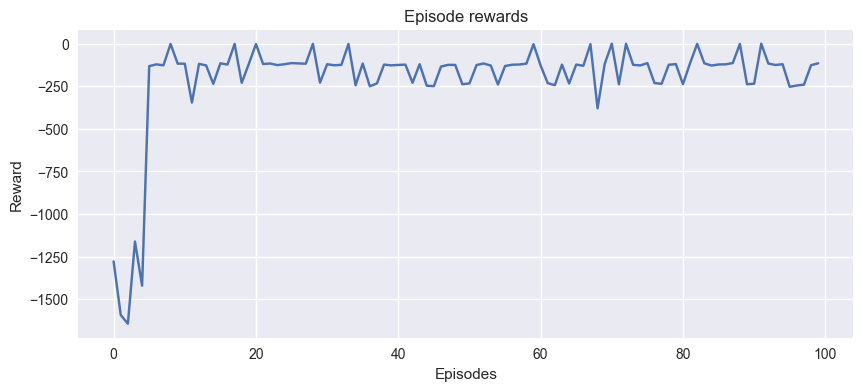

Saved models to models/


In [15]:
# Run a short training session (example)
# Note: adjust max_timesteps for full training; this is a short run for demonstration
params['max_timesteps'] = 20000
params['start_timesteps'] = 1000
params['batch_size'] = 128

results = train_td3(env, actor, critic, actor_target, critic_target,
                    actor_optimizer, critic_optimizer, replay_buffer, params)

print('Finished training (short run).')
mean_eval, std_eval = evaluate_policy(env, actor, episodes=5)
print(f'Eval mean return: {mean_eval:.2f} +/- {std_eval:.2f}')

plot_training(results)
save_models(prefix='td3_a_chabbaki')
